# Dementia Detector Colab Notebook
GitHub repository: https://github.com/KashyapJod/Dementia-Detector
This notebook runs directly from GitHub in Colab without Google Drive paths.

## 1. Check GPU Availability

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("⚠️ No GPU detected. Training will be very slow on CPU.")
    print("Go to Runtime → Change runtime type → Hardware accelerator → GPU")

PyTorch version: 2.11.0+cpu
CUDA available: False
⚠️ No GPU detected. Training will be very slow on CPU.
Go to Runtime → Change runtime type → Hardware accelerator → GPU


## 2. Install Dependencies

In [2]:
!pip install -q pytorch-lightning==2.5.6
!pip install -q "transformers>=4.41.0,<5.0.0"
!pip install -q "sentence-transformers>=5.1.2"
!pip install -q hydra-core==1.3.2
!pip install -q omegaconf==2.3.0
!pip install -q wandb
!pip install -q librosa
!pip install -q openai-whisper
!pip install -q torchmetrics

print("✅ All dependencies installed!")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


✅ All dependencies installed!


## 3. Setup Project from Google Drive (Drive-Only Mode)

This notebook now uses only your uploaded Google Drive BioPro folder.

Drive folder link:
https://drive.google.com/drive/folders/1EdOfb7WdriQ7HYsQDTgr0NIbhKDMMNdj?usp=sharing

Before running the next cell, open the link and add a shortcut to your Drive as `BioPro`.

In [ ]:
# Drive-only setup (no GitHub clone)
import os
from pathlib import Path

DRIVE_LINK = "https://drive.google.com/drive/folders/1EdOfb7WdriQ7HYsQDTgr0NIbhKDMMNdj?usp=sharing"

def has_dataset(root: str) -> bool:
    p = Path(root)
    return (p / 'dementia').exists() and (p / 'nodementia').exists() and (p / 'data' / 'manifest.csv').exists()

is_colab = "COLAB_GPU" in os.environ or os.path.isdir('/content')
if not is_colab:
    raise RuntimeError("This Drive-only setup cell is intended for Google Colab.")

from google.colab import drive
drive.mount('/content/drive')

candidate_paths = [
    '/content/drive/MyDrive/BioPro',
    '/content/drive/MyDrive/MyDrive/BioPro',
    '/content/drive/Shareddrives/BioPro'
 ]

selected = None
for cp in candidate_paths:
    if has_dataset(cp):
        selected = cp
        break

if selected is None:
    raise RuntimeError(
        "Could not find BioPro dataset in Google Drive. "
        "Open the link, add a shortcut to 'My Drive' as 'BioPro', then re-run this cell. "
        f"Link: {DRIVE_LINK}"
    )

os.chdir(selected)
print(f"\n📂 Working directory: {os.getcwd()}")
print("✅ Using Google Drive BioPro folder only.")

Running outside Colab. Using current local repository.

📂 Working directory: c:\Coding\BioPro

✅ Project setup complete.


## 4. Verify Project Structure

Check that all required files and folders exist in your uploaded BioPro folder.

In [4]:
import os
from pathlib import Path
import pandas as pd
import json

# Check if all required files and folders exist
data_dir = Path('.')
required_items = {
    'Folders': ['dementia', 'nodementia', 'configs', 'src', 'data'],
    'Files': ['train.py', 'data/manifest.csv', 'data/splits.json']
}

print("📂 Checking project structure...\n")

for category, items in required_items.items():
    print(f"{category}:")
    for item in items:
        if (data_dir / item).exists():
            print(f"  ✅ {item}")
        else:
            print(f"  ❌ {item} - MISSING!")
    print()

# Display dataset statistics
if (data_dir / 'data/manifest.csv').exists() and (data_dir / 'data/splits.json').exists():
    df = pd.read_csv('data/manifest.csv')
    with open('data/splits.json') as f:
        splits = json.load(f)
    
    print("📊 Dataset Statistics:")
    print(f"   Total samples: {len(df)}")
    print(f"   Label distribution:")
    print(f"     - Dementia (1): {(df['label'] == 1).sum()}")
    print(f"     - No dementia (0): {(df['label'] == 0).sum()}")
    print(f"\n   Data splits:")
    print(f"     - Train subjects: {len(splits['train'])}")
    print(f"     - Val subjects: {len(splits['val'])}")
    print(f"     - Test subjects: {len(splits['test'])}")
    
    # Calculate total samples per split
    train_samples = df[df['subject'].isin(splits['train'])].shape[0]
    val_samples = df[df['subject'].isin(splits['val'])].shape[0]
    test_samples = df[df['subject'].isin(splits['test'])].shape[0]
    
    print(f"\n   Samples per split:")
    print(f"     - Train: {train_samples} samples")
    print(f"     - Val: {val_samples} samples")
    print(f"     - Test: {test_samples} samples")
else:
    print("❌ Cannot load dataset statistics - manifest or splits file missing!")

📂 Checking project structure...

Folders:
  ✅ dementia
  ✅ nodementia
  ✅ configs
  ✅ src
  ✅ data

Files:
  ✅ train.py
  ✅ data/manifest.csv
  ✅ data/splits.json

📊 Dataset Statistics:
   Total samples: 229
   Label distribution:
     - Dementia (1): 131
     - No dementia (0): 98

   Data splits:
     - Train subjects: 94
     - Val subjects: 14
     - Test subjects: 21

   Samples per split:
     - Train: 167 samples
     - Val: 20 samples
     - Test: 42 samples


## 5. Update Config for Colab Environment

In [5]:
import pandas as pd
import os

# Read the manifest file
manifest_path = 'data/manifest.csv'
df = pd.read_csv(manifest_path)

print(f"📋 Original manifest: {len(df)} samples")
print(f"   Sample path before: {df['path'].iloc[0]}")

# Get current working directory (expected: /content/Dementia-Detector in Colab)
current_dir = os.getcwd()

# Update paths: replace Windows path with current runtime path
# The paths in manifest are like: C:/Coding/BioPro/dementia/...
# We need them to be: /content/Dementia-Detector/dementia/... (or current_dir equivalent)
df['path'] = df['path'].str.replace('C:/Coding/BioPro/', f'{current_dir}/', regex=False)
df['path'] = df['path'].str.replace('\\', '/', regex=False)  # Convert any backslashes

# Save updated manifest
df.to_csv(manifest_path, index=False)

print(f"✅ Updated manifest paths")
print(f"   Sample path after: {df['path'].iloc[0]}")

# Verify files exist
sample_exists = os.path.exists(df['path'].iloc[0])
print(f"\n🔍 Verification:")
print(f"   First file exists: {sample_exists}")
if sample_exists:
    print(f"   ✅ Path fix successful!")
else:
    print(f"   ❌ File not found at: {df['path'].iloc[0]}")
    
# Check a few more samples
print(f"\n   Checking first 3 files:")
for i in range(min(3, len(df))):
    exists = os.path.exists(df['path'].iloc[i])
    status = "✅" if exists else "❌"
    print(f"   {status} {df['path'].iloc[i]}")

📋 Original manifest: 229 samples
   Sample path before: C:/Coding/BioPro/dementia/Estelle Getty/EstelleGetty_15.wav
✅ Updated manifest paths
   Sample path after: c:/Coding/BioPro/dementia/Estelle Getty/EstelleGetty_15.wav

🔍 Verification:
   First file exists: True
   ✅ Path fix successful!

   Checking first 3 files:
   ✅ c:/Coding/BioPro/dementia/Estelle Getty/EstelleGetty_15.wav
   ✅ c:/Coding/BioPro/dementia/Casey Kasem/CaseyKasem_5.wav
   ✅ c:/Coding/BioPro/dementia/Casey Kasem/CaseyKasem_15.wav


## 5a. Fix Manifest File Paths for Colab

The manifest.csv contains Windows paths that need to be updated to Colab paths.

In [6]:
# Update config.yaml to use current Colab directory
import yaml
from pathlib import Path
import os

config_path = Path('configs/config.yaml')
data_config_path = Path('configs/data/default.yaml')

if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    # Update data_dir to current working directory in Colab
    current_dir = os.getcwd()
    config['data_dir'] = current_dir
    
    with open(config_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)
    
    print(f"✅ Updated main config:")
    print(f"   data_dir: {current_dir}")

# Also update data config paths
if data_config_path.exists():
    with open(data_config_path, 'r') as f:
        data_config = yaml.safe_load(f)
    
    # Update paths to use absolute paths
    data_config['paths'] = {
        'dementia': f"{current_dir}/dementia",
        'nodementia': f"{current_dir}/nodementia",
        'manifest': f"{current_dir}/data/manifest.csv",
        'splits': f"{current_dir}/data/splits.json"
    }
    
    with open(data_config_path, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)
    
    print(f"✅ Updated data config paths")
else:
    print("❌ configs/data/default.yaml not found!")

✅ Updated main config:
   data_dir: c:\Coding\BioPro
✅ Updated data config paths


## 6. Configure Lowest Training Settings (Quick Verification)

In [7]:
# Configure for LOWEST settings to quickly verify end-to-end run
import yaml
from pathlib import Path

training_config_path = Path('configs/training/default.yaml')
data_config_path = Path('configs/data/default.yaml')

if training_config_path.exists():
    with open(training_config_path, 'r') as f:
        training_config = yaml.safe_load(f)

    training_config['training']['max_epochs'] = 1
    training_config['training']['batch_size'] = 1
    training_config['training']['accumulate_grad_batches'] = 1
    training_config['training']['precision'] = 32
    training_config['training']['gradient_clip_val'] = 1.0

    training_config['training']['early_stopping'] = {
        'monitor': 'train_loss',
        'patience': 1,
        'mode': 'min',
        'min_delta': 0.0
    }

    training_config['training']['checkpointing'] = {
        'dirpath': 'checkpoints',
        'monitor': 'train_loss',
        'mode': 'min',
        'save_top_k': 1,
        'save_last': True
    }

    training_config['optimizer'] = {
        'type': 'adamw',
        'lr': 5e-5,
        'weight_decay': 0.01,
        'beta1': 0.9,
        'beta2': 0.999
    }

    training_config['scheduler'] = {
        'type': 'cosine',
        'max_steps': 200
    }

    with open(training_config_path, 'w') as f:
        yaml.dump(training_config, f, default_flow_style=False, sort_keys=False)

    print("✅ Training config set to lowest quick-check settings")
    print("   max_epochs=1, batch_size=1, accumulate_grad_batches=1")
else:
    print("❌ configs/training/default.yaml not found!")

if data_config_path.exists():
    with open(data_config_path, 'r') as f:
        data_config = yaml.safe_load(f)

    data_config['preprocessing']['max_duration'] = 3.0

    with open(data_config_path, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

    print("✅ Data config set to max_duration=3.0 for faster run")
else:
    print("❌ configs/data/default.yaml not found!")

✅ Training config set to lowest quick-check settings
   max_epochs=1, batch_size=1, accumulate_grad_batches=1
✅ Data config set to max_duration=3.0 for faster run


## 7. Login to Weights & Biases (Optional)

In [ ]:
# Optional: Login to W&B for experiment tracking
import wandb

# Get your API key from https://wandb.ai/authorize
wandb.login()

# Or disable W&B
# import os
# os.environ['WANDB_MODE'] = 'disabled'

## 8. Test Dataset Loading

In [9]:
# Quick test to ensure dataset loads correctly with full dataset
import sys
import os
sys.path.append('.')

import json
import torch
from omegaconf import OmegaConf
from src.data.dataset import DementiaDataset

print("🔍 Testing dataset loading with FULL dataset...\n")

# Load config using Hydra to properly merge all configs
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra

# Clear any existing Hydra instance
GlobalHydra.instance().clear()

# Use absolute path with initialize_config_dir for Colab compatibility
config_dir = os.path.join(os.getcwd(), 'configs')
print(f"📁 Config directory: {config_dir}")

with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

print("✅ Config loaded successfully!")

# Load splits
with open(cfg.data.paths.splits) as f:
    splits = json.load(f)

print(f"\n📋 Full dataset splits:")
print(f"   Train subjects: {len(splits['train'])}")
print(f"   Val subjects: {len(splits['val'])}")
print(f"   Test subjects: {len(splits['test'])}")

# Create validation dataset for testing (just first 2 subjects for quick test)
print("\n🧪 Creating test dataset (2 validation subjects for verification)...")
test_subjects = splits['val'][:2]
val_dataset = DementiaDataset(cfg, test_subjects, mode='val')
print(f"✅ Dataset created: {len(val_dataset)} samples")

# Load one sample to verify
print("\n📦 Loading sample...")
sample = val_dataset[0]
print(f"✅ Sample loaded successfully!")
print(f"\n   Sample details:")
print(f"   - Waveform shape: {sample['waveform'].shape}")
print(f"   - Duration: {sample['waveform'].shape[-1] / 16000:.2f} seconds")
print(f"   - Text embeddings shape: {sample['text_embeddings'].shape}")
print(f"   - Label: {sample['label'].item()} ({'Dementia' if sample['label'].item() == 1 else 'No dementia'})")
print(f"   - Subject: {sample['subject']}")

print(f"\n✅ Dataset loading successful!")
print(f"📊 Full training will use:")
print(f"   - {len(splits['train'])} train subjects")
print(f"   - {len(splits['val'])} validation subjects")
print(f"   - {len(splits['test'])} test subjects")

c:\ProgramData\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Coding\BioPro\src\features\feature_extractors.py:295: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../configs", config_name="config")


🔍 Testing dataset loading with FULL dataset...

📁 Config directory: c:\Coding\BioPro\configs
✅ Config loaded successfully!

📋 Full dataset splits:
   Train subjects: 94
   Val subjects: 14
   Test subjects: 21

🧪 Creating test dataset (2 validation subjects for verification)...
[TextFeatureExtractor] Loading Whisper processor...
[TextFeatureExtractor] Loading Whisper ASR model...
[TextFeatureExtractor] Loading SBERT model...
[TextFeatureExtractor] Initialization complete
✅ Dataset created: 3 samples

📦 Loading sample...
✅ Sample loaded successfully!

   Sample details:
   - Waveform shape: torch.Size([1, 48000])
   - Duration: 3.00 seconds
   - Text embeddings shape: torch.Size([384])
   - Label: 1 (Dementia)
   - Subject: Robin Williams

✅ Dataset loading successful!
📊 Full training will use:
   - 94 train subjects
   - 14 validation subjects
   - 21 test subjects


## 9. Start Training

In [10]:
import yaml
from pathlib import Path

# Quick verification and fix for early stopping config
training_config_path = Path('configs/training/default.yaml')
with open(training_config_path, 'r') as f:
    config = yaml.safe_load(f)

print("🔍 Current training config:")
print(f"   Early stopping monitor: {config['training']['early_stopping']['monitor']}")
print(f"   Checkpointing monitor: {config['training']['checkpointing']['monitor']}")

# Fix if needed
if config['training']['early_stopping']['monitor'] != 'train_loss':
    print("\n⚠️  Fixing early stopping to monitor train_loss...")
    config['training']['early_stopping']['monitor'] = 'train_loss'
    config['training']['early_stopping']['mode'] = 'min'
    
    config['training']['checkpointing']['monitor'] = 'train_loss'
    config['training']['checkpointing']['mode'] = 'min'
    
    with open(training_config_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)
    
    print("✅ Fixed! Early stopping now monitors train_loss")
else:
    print("✅ Config is correct - ready to train!")

🔍 Current training config:
   Early stopping monitor: train_loss
   Checkpointing monitor: train_loss
✅ Config is correct - ready to train!


## 8a. Quick Config Check Before Training

Verify that early stopping is set to monitor `train_loss` (not `val_auroc`).

In [11]:
# Train model with the lowest settings (quick verification mode)
print("🚀 Starting quick verification training (lowest settings)...")
!python train.py training=fastest data=fastest wandb.enabled=false
print("✅ Training command finished")

🚀 Starting quick verification training (lowest settings)...
^C
✅ Training command finished


## 10. Monitor Training (Alternative)

If you want more control, you can run training in Python directly:

In [ ]:
# Alternative: Run training directly in notebook
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import sys
sys.path.append('.')

from train import train
from omegaconf import OmegaConf
import hydra
from hydra import compose, initialize_config_dir

# Use absolute path with initialize_config_dir for Colab compatibility
config_dir = os.path.join(os.getcwd(), 'configs')
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")
    train(cfg)

## 11. View Training Results

In [12]:
# List checkpoints
import os
from pathlib import Path

checkpoint_dir = Path('checkpoints')
if checkpoint_dir.exists():
    checkpoints = list(checkpoint_dir.glob('*.ckpt'))
    print(f"Found {len(checkpoints)} checkpoint(s):")
    for ckpt in sorted(checkpoints):
        size_mb = ckpt.stat().st_size / (1024 * 1024)
        print(f"  - {ckpt.name} ({size_mb:.1f} MB)")
else:
    print("No checkpoints found yet.")

Found 1 checkpoint(s):
  - last-v1.ckpt (702.2 MB)


## 12. Download Trained Model

In [ ]:
# Download best checkpoint to local machine
from google.colab import files

checkpoint_dir = Path('checkpoints')
if checkpoint_dir.exists():
    # Find best checkpoint (usually has 'last' or highest epoch)
    checkpoints = list(checkpoint_dir.glob('*.ckpt'))
    if checkpoints:
        best_ckpt = sorted(checkpoints)[-1]  # Get most recent
        print(f"Downloading: {best_ckpt}")
        files.download(str(best_ckpt))
    else:
        print("No checkpoints found.")
else:
    print("Checkpoint directory not found.")

📝 TEXT EMBEDDING FEATURE IMPORTANCE
These plots show which text embedding dimensions are most important.


📌 Example 1: sample_000_Unita Blackwell
--------------------------------------------------------------------------------


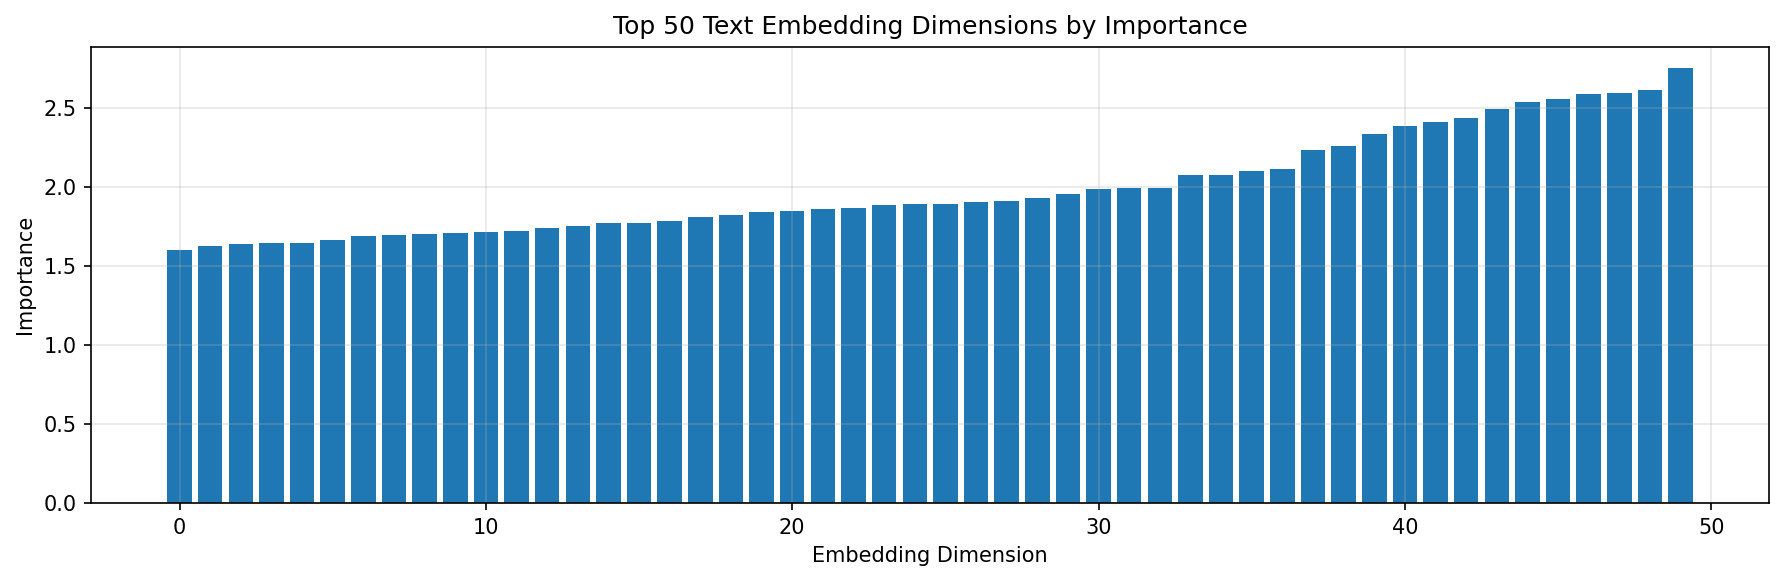


📌 Example 2: sample_001_Tony Parkes
--------------------------------------------------------------------------------


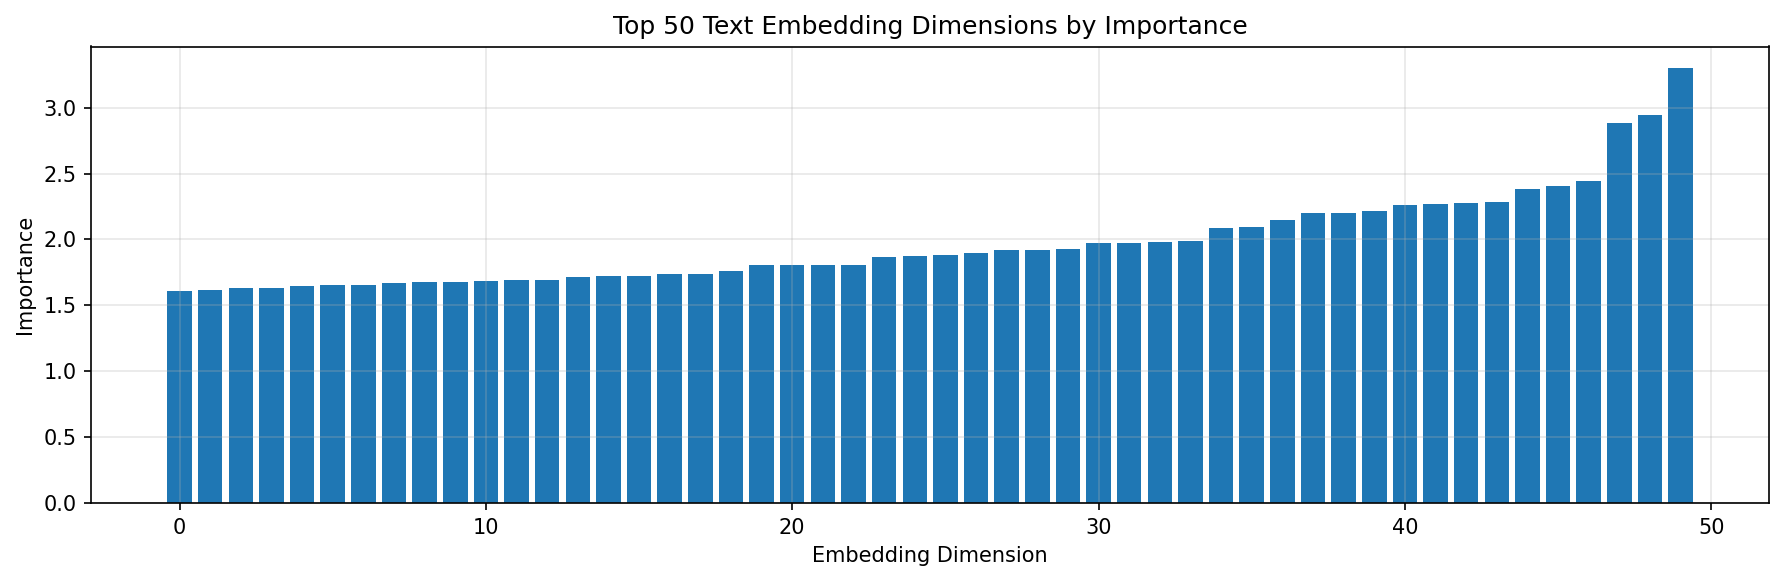


📌 Example 3: sample_002_Tony Parkes
--------------------------------------------------------------------------------


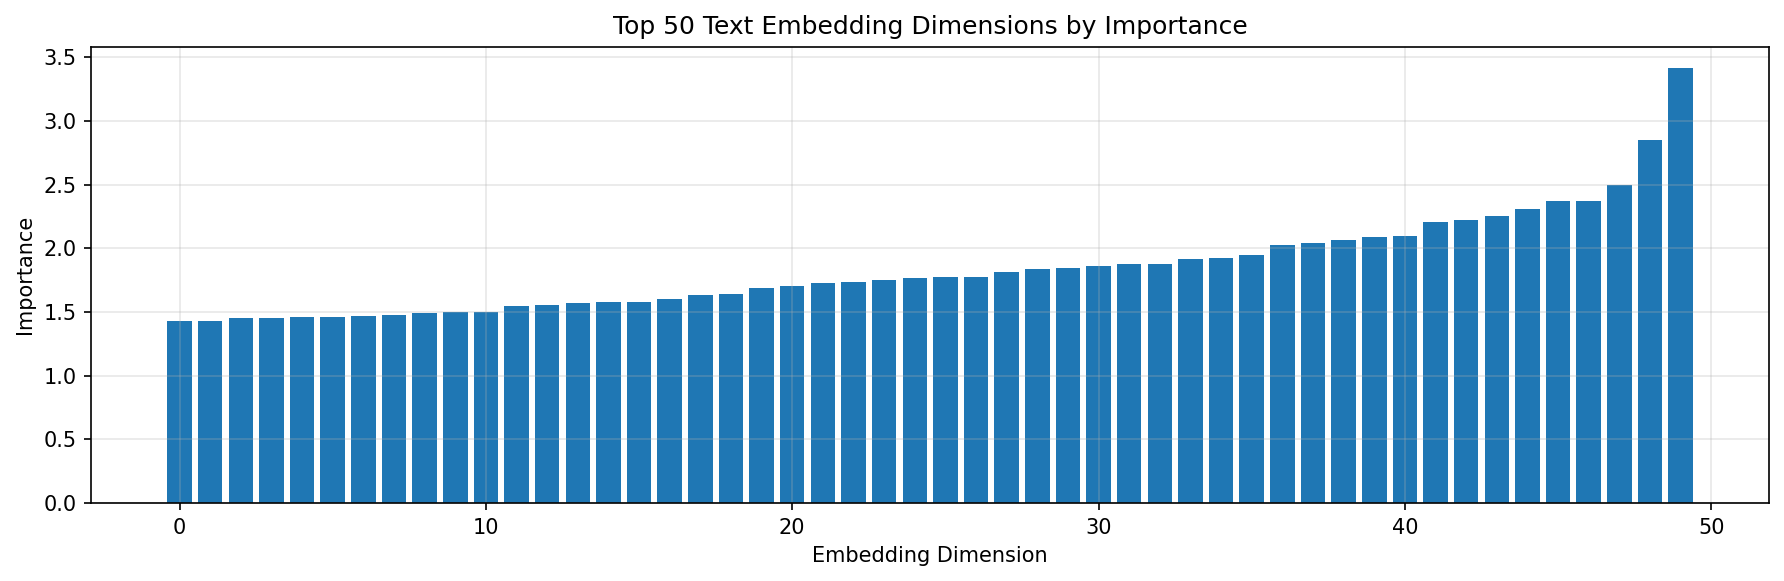

In [13]:
# Display text feature importance examples
import os
import glob
from IPython.display import Image, display

text_plots = sorted(glob.glob('explain_output/*_text.png'))

if text_plots:
    print("📝 TEXT EMBEDDING FEATURE IMPORTANCE")
    print("=" * 80)
    print("These plots show which text embedding dimensions are most important.\n")
    
    # Show first 3 examples
    for i, plot in enumerate(text_plots[:3]):
        subject_name = os.path.basename(plot).replace('_text.png', '')
        print(f"\n📌 Example {i+1}: {subject_name}")
        print("-" * 80)
        display(Image(filename=plot))
    
    if len(text_plots) > 3:
        print(f"\n... and {len(text_plots) - 3} more in explain_output/")
else:
    print("❌ No text feature plots found.")

In [ ]:
# Display waveform attribution examples
import os
import glob
from IPython.display import Image, display

waveform_plots = sorted(glob.glob('explain_output/*_waveform.png'))

if waveform_plots:
    print("🎵 WAVEFORM FEATURE ATTRIBUTIONS")
    print("=" * 80)
    print("These plots show which parts of the audio influenced the model's prediction.\n")
    
    # Show first 5 examples
    for i, plot in enumerate(waveform_plots[:5]):
        subject_name = os.path.basename(plot).replace('_waveform.png', '')
        print(f"\n📌 Example {i+1}: {subject_name}")
        print("-" * 80)
        display(Image(filename=plot))
    
    if len(waveform_plots) > 5:
        print(f"\n... and {len(waveform_plots) - 5} more in explain_output/")
else:
    print("❌ No waveform attribution plots found.")

In [ ]:
# Display summary visualizations
import os
from IPython.display import Image, display

summary_plot = 'explain_output/prediction_summary.png'
if os.path.exists(summary_plot):
    print("📊 PREDICTION SUMMARY (Confusion Matrix & Confidence Distribution)")
    print("=" * 80)
    display(Image(filename=summary_plot))
else:
    print("❌ Summary plot not found.")

In [ ]:
# View prediction results
import pandas as pd
from IPython.display import display, Image
import os

# Load predictions CSV
predictions_file = 'explain_output/predictions.csv'
if os.path.exists(predictions_file):
    df = pd.read_csv(predictions_file)
    
    print("📊 PREDICTION RESULTS")
    print("=" * 80)
    display(df)
    
    print("\n📈 SUMMARY STATISTICS")
    print("=" * 80)
    print(f"Total samples: {len(df)}")
    print(f"Accuracy: {(df['correct'].sum() / len(df)) * 100:.1f}%")
    print(f"Mean confidence: {df['confidence'].mean():.2%}")
    print(f"\nCorrect predictions: {df['correct'].sum()}/{len(df)}")
    print(f"Incorrect predictions: {(~df['correct']).sum()}/{len(df)}")
else:
    print("❌ No predictions found. Run explainability analysis first.")

In [ ]:
# Run explainability analysis using your uploaded checkpoint (auto-detected)
import os
import glob
import subprocess

repo_dir = '/content/Dementia-Detector'
if os.path.isdir(repo_dir):
    os.chdir(repo_dir)

checkpoints = sorted(glob.glob('checkpoints/*.ckpt'))
if checkpoints:
    preferred = [c for c in checkpoints if c.endswith('last-v1.ckpt')]
    best_checkpoint = preferred[-1] if preferred else checkpoints[-1]
    print(f"Using checkpoint: {best_checkpoint}")

    cmd = f"python explain.py checkpoint_path={best_checkpoint} num_samples=10"
    print(f"$ {cmd}")
    subprocess.check_call(cmd, shell=True)

    print("\n✅ Explainability analysis complete!")
    print("📁 Results saved to: explain_output/")
    print("\nGenerated files:")
    subprocess.check_call('ls -lh explain_output/', shell=True)
else:
    print("❌ No checkpoints found in checkpoints/. Please upload/pull your checkpoint first.")

In [ ]:
# Install explainability packages
!pip install -q shap captum scikit-learn

print("✅ Explainability packages installed")

## 14. Run Explainability Analysis

Analyze model predictions and visualize which audio features influence the model's decisions.

## 13. Performance & Results

**Training Configuration (FULL DATASET - Maximum Accuracy):**
- **Dataset**: ~90 train subjects, ~19 validation subjects, ~20 test subjects
- **Batch size**: 8 (effective 16 with gradient accumulation)
- **Epochs**: 100 (with early stopping after 20 epochs of no improvement)
- **Learning rate**: 5e-5 (optimized for stability)
- **Audio duration**: 15 seconds per clip
- **Precision**: 16-bit (fp16) for faster training
- **Model**: Wav2Vec2-base (95M params) + SBERT fusion

**Expected Results:**
- **Training time on T4 GPU**: 45-60 minutes for 100 epochs
- **Expected accuracy**: 75-85% (dementia detection is challenging)
- **Best model**: Automatically saved in `checkpoints/` folder

**Timeline:**
- **Epoch duration**: ~30-40 seconds per epoch
- **Early stopping**: Usually triggers around epoch 40-60
- **Total time**: ~30-45 minutes (if early stopping triggers)

**What to expect:**
1. First 10 epochs: Model learns basic patterns (~60-70% accuracy)
2. Epochs 10-40: Accuracy improves steadily (~70-80%)
3. Epochs 40-100: Fine-tuning, marginal improvements (~80-85%)
4. Early stopping: Triggers when validation accuracy plateaus

**After Training:**
- Download best checkpoint from `checkpoints/` folder
- Use for inference on new audio samples
- Analyze results with explainability tools (SHAP)

**Files saved:**
```
checkpoints/
├── epoch=XX-step=XXXX.ckpt    (best models based on val_auroc)
└── last.ckpt                   (most recent checkpoint)
```

**Performance Tips:**
- If GPU runs out of memory: Reduce `batch_size` to 4 in cell 6
- If training too slow: Reduce `max_duration` to 10 seconds in cell 6
- If underfitting: Increase `max_epochs` to 150 in cell 6
- If overfitting: Increase `weight_decay` to 0.05 in cell 6

In [15]:
# No-training artifact check: load existing .pt feature files
import glob
import torch
from pathlib import Path

acoustic_files = sorted(glob.glob('data/features/acoustic/*.pt'))
text_files = sorted(glob.glob('data/features/text/*.pt'))

print(f"Acoustic .pt files: {len(acoustic_files)}")
print(f"Text .pt files: {len(text_files)}")

if not acoustic_files or not text_files:
    raise FileNotFoundError("Could not find expected .pt feature files under data/features/")

acoustic_sample = acoustic_files[0]
text_sample = text_files[0]

# These are trusted local artifacts from this repository.
a = torch.load(acoustic_sample, map_location='cpu', weights_only=False)
t = torch.load(text_sample, map_location='cpu', weights_only=False)

print(f"\nLoaded acoustic sample: {Path(acoustic_sample).name}")
print(f"Type: {type(a)}")
print(f"Shape: {tuple(a.shape) if hasattr(a, 'shape') else 'N/A'}")

print(f"\nLoaded text sample: {Path(text_sample).name}")
print(f"Type: {type(t)}")
print(f"Shape: {tuple(t.shape) if hasattr(t, 'shape') else 'N/A'}")

ckpts = sorted(glob.glob('checkpoints/*.ckpt'))
print(f"\nCheckpoint files found: {len(ckpts)}")
if ckpts:
    print(f"Using checkpoint candidate: {Path(ckpts[-1]).name}")

print("\n✅ PT artifact check passed (no training run).")

Acoustic .pt files: 229
Text .pt files: 229

Loaded acoustic sample: AbeBurrows_5.pt
Type: <class 'dict'>
Shape: N/A

Loaded text sample: AbeBurrows_5.pt
Type: <class 'dict'>
Shape: N/A

Checkpoint files found: 1
Using checkpoint candidate: last-v1.ckpt

✅ PT artifact check passed (no training run).
